In [1]:
import tensorflow as tf

# compute feature for database
model = tf.keras.applications.VGG16(include_top=False, 
                                    weights='imagenet', 
                                    input_shape=(128, 128, 3))

model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

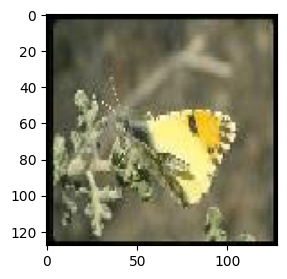

In [2]:
# load query
import matplotlib
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as kimage

query = kimage.load_img('image1.jpg', target_size=(128, 128))

plt.figure(figsize=(3,3))
plt.imshow(query)
plt.show()

In [12]:
kimage.img_to_array(query)[:,:,1]

array([[ 3.,  0.,  0., ...,  1.,  0.,  5.],
       [ 3.,  0.,  0., ...,  1.,  0.,  5.],
       [ 0.,  0.,  0., ...,  7.,  0.,  0.],
       ...,
       [12., 13., 12., ..., 81., 10.,  1.],
       [ 0.,  0.,  0., ..., 11.,  2.,  2.],
       [ 0.,  0.,  0., ..., 11.,  2.,  2.]], dtype=float32)

In [13]:
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

image1 = kimage.load_img('image1.jpg', target_size=(128, 128))

# compute features for query
image1_np = kimage.img_to_array(image1)        # (128,128,3)
image1_np = np.expand_dims(image1_np, axis=0)  # (1, 128,128,3)
#image1_np = preprocess_input(image1_np)       # (1, 128,128,3)

image1_features = model.predict(image1_np)
print(image1_features.shape)

1/1 [==============================] - 0s 219ms/step
(1, 4, 4, 512)


In [14]:
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

image2 = kimage.load_img('image2.jpg', target_size=(128, 128))

# compute features for query
image2_np = kimage.img_to_array(image2)       # (128,128,3)
image2_np = np.expand_dims(image2_np, axis=0) # (1, 128,128,3)
#image2_np = preprocess_input(image2_np)       # (1, 128,128,3)

image2_features = model.predict(image2_np)
print(image2_features.shape)

1/1 [==============================] - 0s 93ms/step
(1, 4, 4, 512)


## CNN + Cosine

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# compute similarity
image1_features = np.reshape(image1_features, (1, -1))
image2_features = np.reshape(image2_features,(1, -1))

sims = cosine_similarity(image1_features, image2_features).squeeze()
print(sims)

0.3138166


## CNN + Correlation

In [16]:
from scipy.stats import pearsonr

# compute similarity
image1_features = np.reshape(image1_features, (-1,))
image2_features = np.reshape(image2_features, (-1,))

sims = pearsonr(image1_features, image2_features)
print(sims)

PearsonRResult(statistic=0.27642164224626886, pvalue=1.3885447376972746e-143)


## CNN + abs

In [17]:
# compute similarity
image1_features = np.reshape(image1_features, (-1,))
image2_features = np.reshape(image2_features, (-1,))

sims = np.absolute(image1_features, image2_features).mean()
print(sims)

1.8328533
